In [24]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [25]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [26]:
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

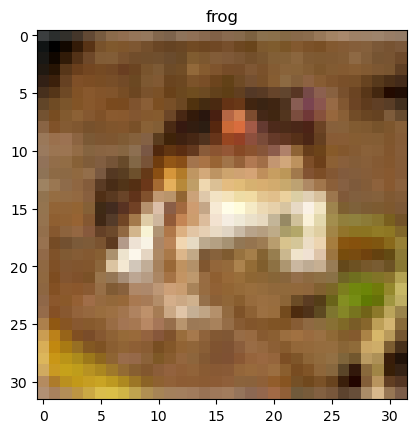

In [27]:
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.show()

In [28]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [29]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [30]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [31]:
model.fit(
x_train,
y_train,
epochs=10,
validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.4731 - loss: 1.4660 - val_accuracy: 0.5611 - val_loss: 1.2280
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 29ms/step - accuracy: 0.6004 - loss: 1.1332 - val_accuracy: 0.6252 - val_loss: 1.0651
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.6523 - loss: 1.0007 - val_accuracy: 0.6468 - val_loss: 1.0164
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6838 - loss: 0.9136 - val_accuracy: 0.6720 - val_loss: 0.9548
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.7044 - loss: 0.8469 - val_accuracy: 0.6736 - val_loss: 0.9459
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7248 - loss: 0.7956 - val_accuracy: 0.6875 - val_loss: 0.9188
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 34ms/step - accuracy: 0.7400 - loss: 0.7439 - val_accuracy: 0.6954 - val_loss: 0.8920
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.7564 -

In [32]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6863 - loss: 0.9629
Test Accuracy: 0.6862999796867371


In [33]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


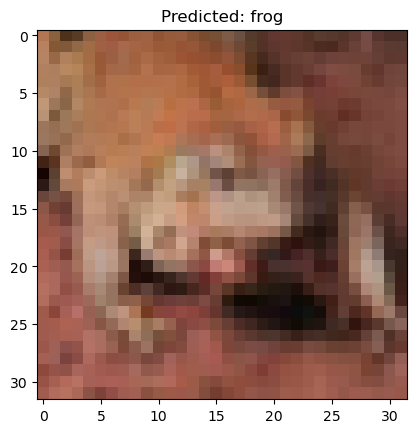

In [34]:
plt.imshow(x_test[5])
plt.title("Predicted: " + class_names[np.argmax(predictions[5])])
plt.show()